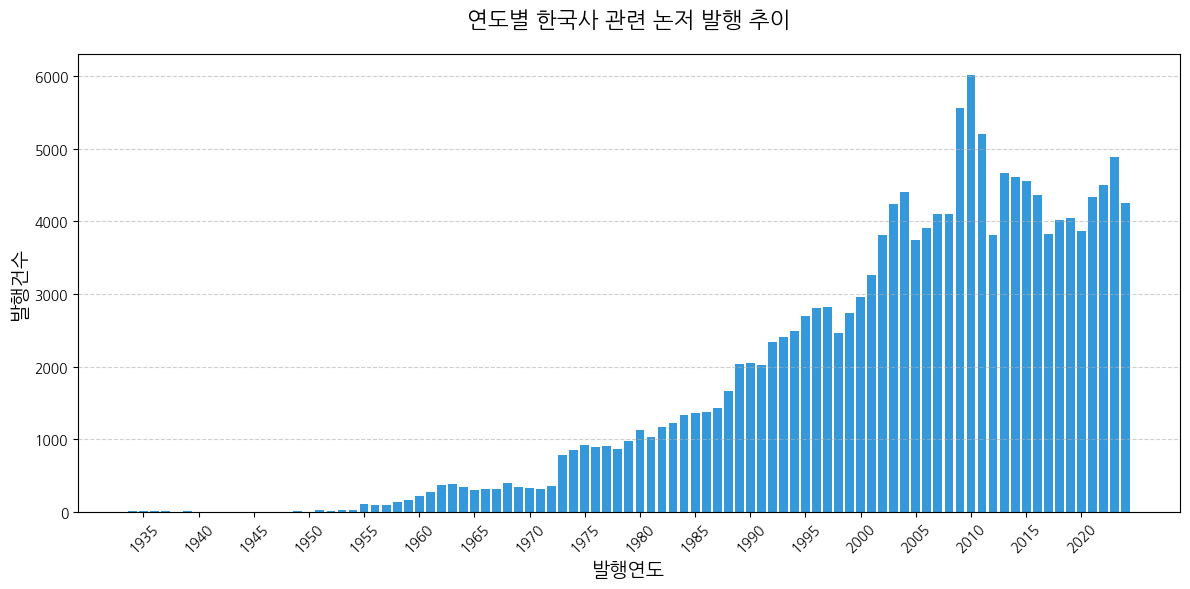

In [3]:
# 4장 첫번째 그래프 # 연도별 한국사 관련 논저 출판건수 막대 그래프
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

# 1. 폰트 설정\
plt.rcParams['font.family'] = 'Nanum Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 로드 및 전처리
try:
    script_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    script_dir = os.getcwd()

data_path = os.path.join(script_dir, '공유_publication_arti_book.csv')

if not os.path.exists(data_path):
    print(f"오류: '{data_path}' 파일이 없습니다.")
    exit()
    
with open(data_path, 'r', encoding='utf-8-sig') as f:
    df = pd.read_csv(f)
    
# 2025년 제외, 결측치 제거, 정수 변환
df_year = df[
    (df['publication_year'].notnull()) & 
    (df['publication_year'] != 2025)
].copy()
df_year['publication_year'] = df_year['publication_year'].astype(int)

# 집계 및 빈 연도 채우기
year_counts = df_year['publication_year'].value_counts().sort_index()
if not year_counts.empty:
    all_years = range(year_counts.index.min(), year_counts.index.max() + 1)
    year_counts = year_counts.reindex(all_years, fill_value=0)

# 3. 시각화
plt.figure(figsize=(12, 6))

plt.bar(
    year_counts.index, 
    year_counts.values, 
    color='#3498db', 
    width=0.8
)

plt.title("연도별 한국사 관련 논저 발행 추이", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("발행연도", fontsize=14, fontweight='bold')
plt.ylabel("발행건수", fontsize=14, fontweight='bold')
xticks_years = [y for y in year_counts.index if y % 5 == 0]
plt.xticks(xticks_years, rotation=45, fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("공유_4_1_연도별 논저발행추이.png", dpi=300, bbox_inches='tight')
plt.show()

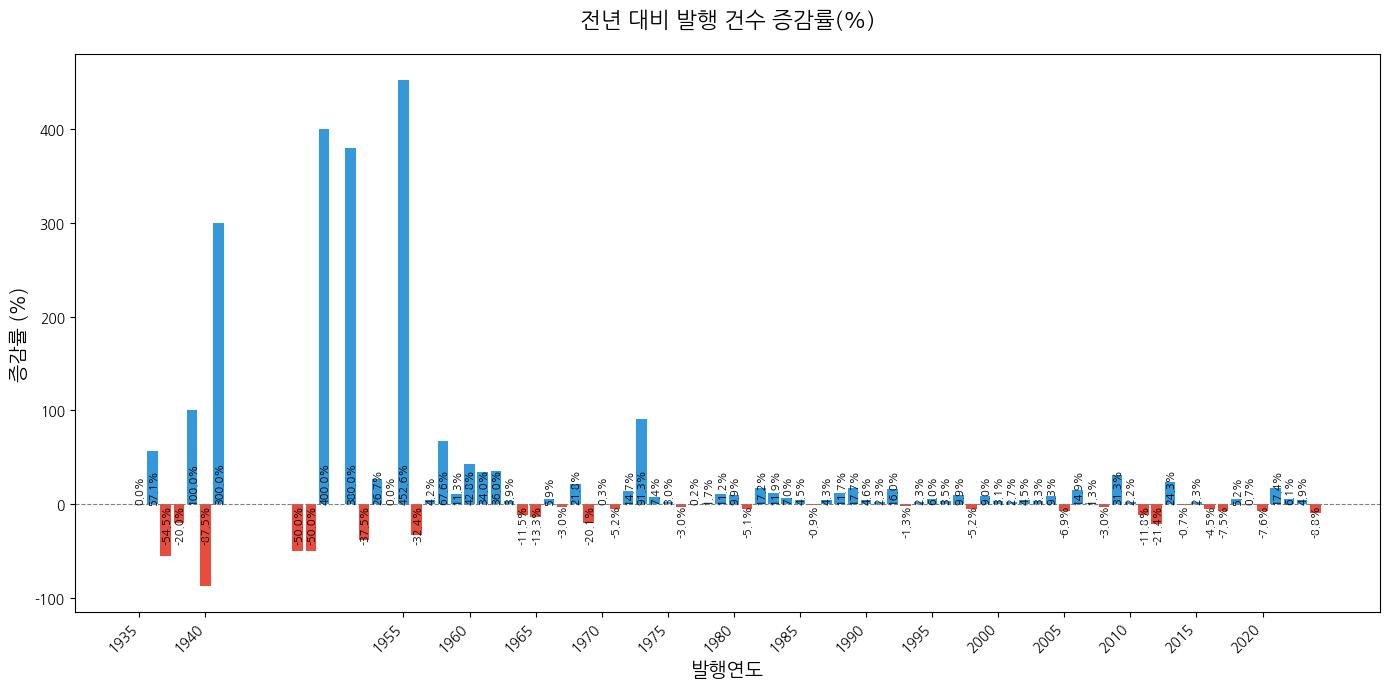

In [5]:
# 4장 첫번째 그래프를 설명하는 증감률 지표 # 본문에는 없음.

import matplotlib.pyplot as plt
import pandas as pd
import os
import numpy as np

# 1. 폰트 설정
plt.rcParams['font.family'] = 'Nanum Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 로드
try:
    script_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    script_dir = os.getcwd()

data_path = os.path.join(script_dir, '공유_publication_arti_book.csv')

if not os.path.exists(data_path):
    print(f"오류: '{data_path}' 파일이 없습니다.")
    exit()

df = pd.read_csv(data_path)

# 3. 데이터 집계 및 증감률 계산 # '논문'만 필터링, 2025년 제외
df_paper = df[
    (df['article_book'] == '논문') & 
    (df['publication_year'].notnull()) & 
    (df['publication_year'] != 2025)
].copy()

df_paper['publication_year'] = df_paper['publication_year'].astype(int)

# 연도별 발행 건수
year_counts = df_paper['publication_year'].value_counts().sort_index()

year_on_year_change = ((year_counts - year_counts.shift(1)) / year_counts.shift(1)) * 100
year_on_year_change = year_on_year_change.dropna()   # 첫 해는 비교 대상이 없으므로 제거

# 4. 시각화
plt.figure(figsize=(14, 7))

colors = ['#3498db' if x >= 0 else '#e74c3c' for x in year_on_year_change]

bars = plt.bar(year_on_year_change.index, year_on_year_change.values, color=colors)
plt.title('전년 대비 발행 건수 증감률(%)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('발행연도', fontsize=14, fontweight='bold')
plt.ylabel('증감률 (%)', fontsize=14, fontweight='bold')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)

xticks_years = [y for y in year_on_year_change.index if y % 5 == 0]
plt.xticks(xticks_years, rotation=45, ha='right', fontsize=10)

for bar in bars:
    height = bar.get_height()
    xval = bar.get_x() + bar.get_width()/2
    plt.text(
        xval, 
        0,
        f'{height:.1f}%', 
        ha='center', 
        va='bottom' if height >= 0 else 'top',
        fontsize=8,
        rotation=90,
        color='black'
    )

plt.tight_layout()
plt.savefig("공유_4_1_2_전년대비발행건수 증감추이.png", dpi=300, bbox_inches='tight')
plt.show()

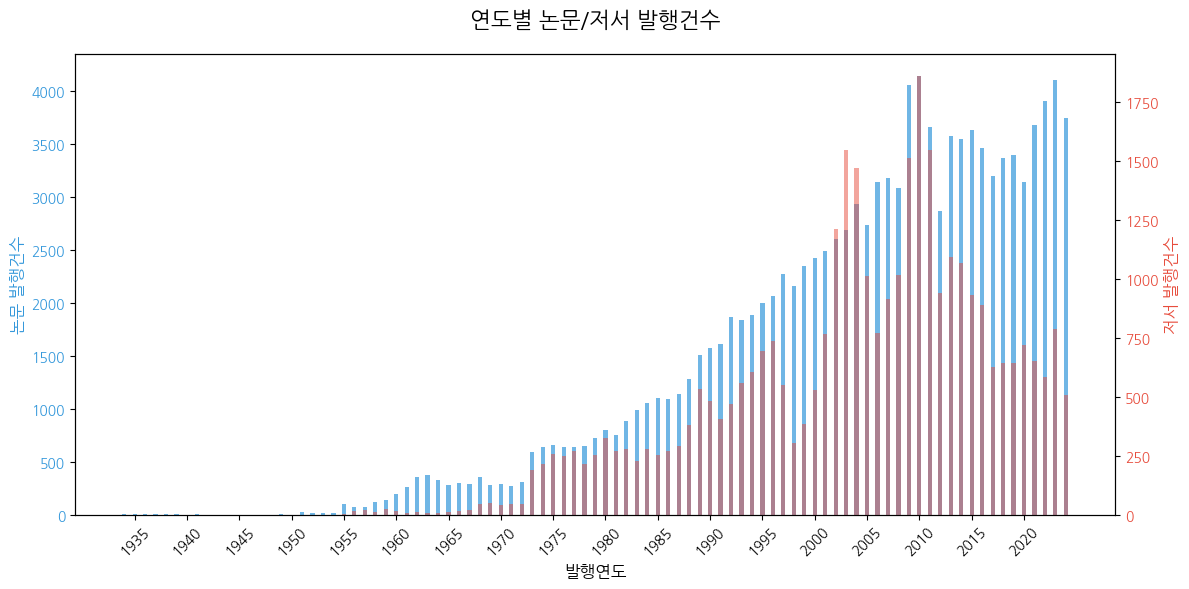

In [7]:
# 4장 두번째 그래프

import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

# 1. 폰트 설정
plt.rcParams['font.family'] = 'Nanum Gothic'  # Windows: 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 로드
try:
    script_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    script_dir = os.getcwd()

data_path = os.path.join(script_dir, '공유_publication_arti_book.csv')

if not os.path.exists(data_path):
    print(f"오류: '{data_path}' 파일을 찾을 수 없습니다.")
    exit()

with open(data_path, 'r', encoding='utf-8-sig') as f:
    df = pd.read_csv(f)

# 3. 데이터 전처리 # 2025년 제외, 결측치 제거, 정수 변환
df_clean = df[
    (df['publication_year'].notnull()) & 
    (df['publication_year'] != 2025)
].copy()
df_clean['publication_year'] = df_clean['publication_year'].astype(int)

# 논문/저서 분리 및 집계
year_counts_paper = df_clean[df_clean['article_book'] == '논문']['publication_year'].value_counts().sort_index()
year_counts_book = df_clean[df_clean['article_book'] == '저서']['publication_year'].value_counts().sort_index()


if not year_counts_paper.empty and not year_counts_book.empty:
    min_year = min(year_counts_paper.index.min(), year_counts_book.index.min())
    max_year = max(year_counts_paper.index.max(), year_counts_book.index.max())
    all_years = range(min_year, max_year + 1)
    year_counts_paper = year_counts_paper.reindex(all_years, fill_value=0)
    year_counts_book = year_counts_book.reindex(all_years, fill_value=0)
else:
    all_years = []

# 4. 시각화
fig, ax1 = plt.subplots(figsize=(12, 6))

# [축 1] 논문 (왼쪽 Y축, 하늘색)
ax1.bar(year_counts_paper.index, year_counts_paper.values, 
        width=0.4, label='논문', color='#3498db', alpha=0.7)
ax1.set_xlabel('발행연도', fontsize=12)
ax1.set_ylabel('논문 발행건수', color='#3498db', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#3498db')

# [축 2] 저서 (오른쪽 Y축, 빨간색)
ax2 = ax1.twinx()
ax2.bar(year_counts_book.index, year_counts_book.values, 
        width=0.4, label='저서', color='#e74c3c', alpha=0.5)
ax2.set_ylabel('저서 발행건수', color='#e74c3c', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#e74c3c')

#5년 단위 X축 눈금 설정
if len(all_years) > 0:
    xticks_years = [y for y in all_years if y % 5 == 0]
    ax1.set_xticks(xticks_years)
    ax1.set_xticklabels(xticks_years, rotation=45, fontsize=10)

plt.title("연도별 논문/저서 발행건수", fontsize=16, fontweight='bold', pad=20)
fig.tight_layout()
plt.savefig("공유_4_2_연도별논문및저서발행추이.png", dpi=300, bbox_inches='tight')
plt.show()

/var/folders/jz/f92mb2011kb6b2qw8y4qw_s40000gn/T/ipykernel_51704/1942750438.py:86: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df_exploded.pivot_table(


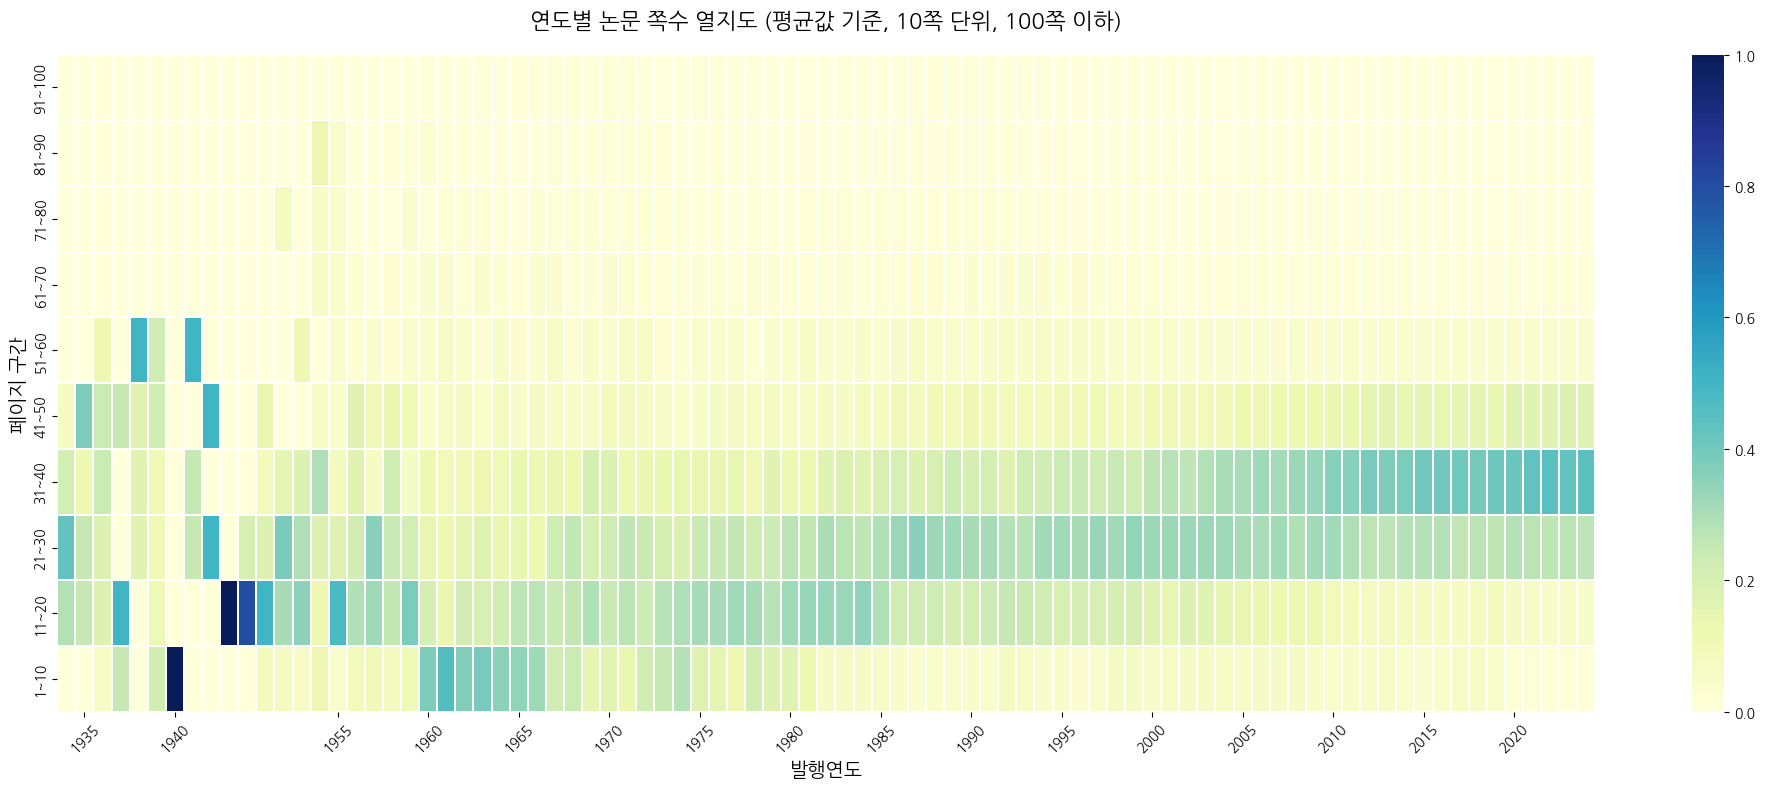

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import re
import os
import platform
from matplotlib import font_manager, rc

# 1. 그래프 폰트 설정
plt.rcParams['font.family'] = 'Nanum Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 로드
try:
    script_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    script_dir = os.getcwd()

data_path = os.path.join(script_dir, '공유_논문쪽수(~100).csv')

if not os.path.exists(data_path):
    print(f"오류: '{data_path}' 파일이 없습니다.")
    exit()
    
with open(data_path, 'r', encoding='utf-8-sig') as f:
    df = pd.read_csv(f)


# 3. 데이터 필터링 및 전처리
df['publication_year'] = pd.to_numeric(df['publication_year'], errors='coerce')

# 필터링: 논문만, 2025년 제외, 연도 있는 것만
df_clean = df[
    (df['article_book'] == '논문') &
    (df['publication_year'].notnull()) & 
    (df['publication_year'] != 2025)
].copy()

df_clean['publication_year'] = df_clean['publication_year'].astype(int)
df_viz = df_clean.copy()

# 4. 리스트 복원 및 Explode
def robust_restore_list(val):
    if isinstance(val, list): return val
    if pd.isna(val) or val == "" or val == "[]": return []
    if isinstance(val, str):
        s = val.strip()
        if ' ' in s and ',' not in s: s = s.replace(' ', ',')
        try:
            result = ast.literal_eval(s)
            if isinstance(result, (tuple, set)): return list(result)
            if isinstance(result, (int, float)): return [result]
            return result
        except (ValueError, SyntaxError):
            numbers = re.findall(r'\d+', s)
            return [int(n) for n in numbers]
    return []

df_viz['page_count_list_fixed'] = df_viz['page_count_list'].apply(robust_restore_list)

# Explode 실행
df_exploded = df_viz.explode('page_count_list_fixed')
df_exploded['page_count_list_fixed'] = pd.to_numeric(df_exploded['page_count_list_fixed'], errors='coerce')

# 결측치 제거
df_exploded = df_exploded.dropna(subset=['page_count_list_fixed'])

initial_count = len(df_exploded)
df_exploded = df_exploded[df_exploded['page_count_list_fixed'] <= 100]
final_count = len(df_exploded)

# 5. 구간설정 및 피벗
max_val = 100
bins = list(range(0, max_val, 10)) + [101]
labels = [f"{i+1}~{i+10}" for i in range(0, max_val, 10)]

df_exploded['page_bin'] = pd.cut(
    df_exploded['page_count_list_fixed'],
    bins=bins,
    labels=labels,
    right=False
)

pivot = df_exploded.pivot_table(
    index='page_bin',
    columns='publication_year',
    values='page_count_list_fixed',
    aggfunc='count',
    fill_value=0
)

# 정규화
pivot_norm = pivot.div(pivot.sum(axis=0), axis=1).fillna(0)

# 6. 히트맵 시각화    
# 히트맵 그리기
plt.figure(figsize=(20, 8))
ax = sns.heatmap(pivot_norm, cmap='YlGnBu', linewidths=0.2, annot=False)

plt.title('연도별 논문 쪽수 열지도 (평균값 기준, 10쪽 단위, 100쪽 이하)', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('페이지 구간', fontsize=14, fontweight='bold')
plt.xlabel('발행연도', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
if not pivot_norm.columns.empty:
    years = pivot_norm.columns.tolist()
    # 히트맵 셀 중앙(idx + 0.5)에 눈금 위치 지정
    tick_locs = [i + 0.5 for i, y in enumerate(years) if y % 5 == 0]
    tick_labels = [y for y in years if y % 5 == 0]
    plt.xticks(tick_locs, tick_labels, rotation=45, fontsize=10)

plt.tight_layout()

# 이미지 저장
save_path = os.path.join(script_dir, "공유_4_3_연도별논문쪽수분포열지도_100_이하.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()